# Approaches to vector semantics

By [Allison Parrish](http://www.decontextualize.com/) for [Human Scale Natural Language Processing](https://hsnlp.decontextualize.com/)

This tutorial reuses some material from [Understanding word vectors](https://github.com/aparrish/rwet/blob/master/understanding-word-vectors.ipynb), which you might review if you're interested in a more thorough explanation that includes pre-trained word vectors (e.g. word2vec, GloVe).

In [ ]:
%pip install pandas numpy matplotlib

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('ggplot')

A *vector* is a series of numbers, often used to describe coordinates or directions in a geometric space ([see Dan Shiffman's explanation of "vector" in that context](https://natureofcode.com/vectors/)). [Linear algebra](https://en.wikipedia.org/wiki/Linear_algebra) is the branch of mathematics that deals with vectors (among other things), and the techniques used in linear algebra are not just powerful but also amenable to computation. As a consequence, a great deal of machine learning algorithms operate on vectors, and the first step of working with some phenomenon in the real world is often to find a way to represent that phenomenon as a vector.

A *word vector*, broadly construed, is simply a vector representation of a word, usually of the word's meaning. There are many systems for producing word vectors, ranging from [asking undergrads to score words on a scale](https://link.springer.com/article/10.3758/bf03201693) to [tf-idf](https://en.wikipedia.org/wiki/Tf%E2%80%93idf) to [word2vec](https://en.wikipedia.org/wiki/Word2vec). Generally, word vectors have the property that any two words with similar vectors are also similar in meaning.

We can view word vectors broadly as a computational extension of [lexical semantics](https://en.wikipedia.org/wiki/Lexical_semantics): the study of word meanings. Of course, words are only one possible unit of language that we might choose to analyze, and it's simply untrue that "meaning" is something that inheres in individual units, rather than discourse and context and whatever else. Nevertheless, working with word vectors as a way to analyze and manipulate language can be fun and useful.

# Why word vectors for poetry?

Tzara proposed a method of composing a Dada poem: cut out the words of a text, shake them in a bag, then write down the words as you remove them at random from the bag. The very idea caused a riot and sundered the avant garde in twain (or so the story goes). For poets, word vectors are (for better or worse) a tool to help soften the blow of cut-up techniques: instead of selecting words at random, we might select units of text that are *close in meaning* to other units. This can yield poetic juxtapositions with subtle effects impossible to achieve with other techniques.

Also, it's fun!

# Starting with a smaller problem: animal similarity and simple linear algebra

We'll begin by considering a small subset of English: words for animals. Our task is to be able to write computer programs to find similarities among these words and the creatures they designate. To do this, we might start by making a spreadsheet of some animals and their characteristics. In Python, you'd define such a spreadsheet like this:

In [2]:
animals = [
    {'name': 'kitten', 'cuteness': 95, 'size': 15},
    {'name': 'hamster', 'cuteness': 80, 'size': 8},
    {'name': 'tarantula', 'cuteness': 8, 'size': 3},
    {'name': 'puppy', 'cuteness': 90, 'size': 20},
    {'name': 'crocodile', 'cuteness': 5, 'size': 40},
    {'name': 'dolphin', 'cuteness': 60, 'size': 45},
    {'name': 'panda bear', 'cuteness': 75, 'size': 40},
    {'name': 'lobster', 'cuteness': 2, 'size': 15},
    {'name': 'capybara', 'cuteness': 70, 'size': 30},
    {'name': 'elephant', 'cuteness': 65, 'size': 90},
    {'name': 'mosquito', 'cuteness': 1, 'size': 1},
    {'name': 'goldfish', 'cuteness': 25, 'size': 2},
    {'name': 'horse', 'cuteness': 50, 'size': 50},
    {'name': 'chicken', 'cuteness': 25, 'size': 15}
]
animal_lookup = {item['name']: (item['cuteness'], item['size']) for item in animals}

And then display it:

In [3]:
pd.DataFrame(animals, columns=['name', 'cuteness', 'size'])

,name,cuteness,size
0,kitten,95,15
1,hamster,80,8
2,tarantula,8,3
3,puppy,90,20
4,crocodile,5,40
5,dolphin,60,45
6,panda bear,75,40
7,lobster,2,15
8,capybara,70,30
9,elephant,65,90


This table associates a handful of animals with two numbers: their cuteness and their size, both in a range from zero to one hundred. (The values themselves are simply based on my own judgment. Your taste in cuteness and evaluation of size may differ significantly from mine. As with all data, these data are simply a mirror reflection of the person who collected them.)

These values give us everything we need to make determinations about which animals are similar (at least, similar in the properties that we've included in the data). Try to answer the following question: Which animal is most similar to a capybara? You could go through the values one by one and do the math to make that evaluation, but visualizing the data as points in 2-dimensional space makes finding the answer very intuitive:

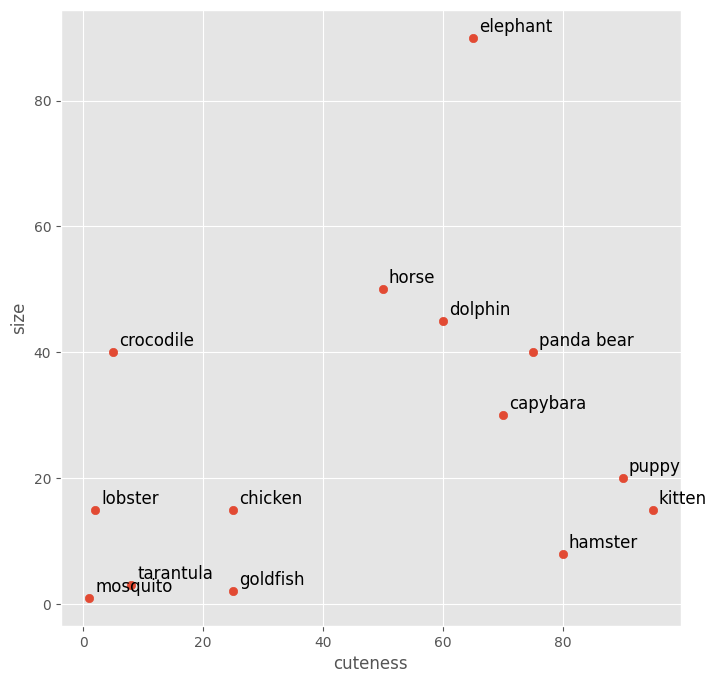

In [4]:
plt.figure(figsize=(8, 8))
plt.scatter([item[0] for item in animal_lookup.values()],
            [item[1] for item in animal_lookup.values()])
plt.xlabel('cuteness')
plt.ylabel('size')
for label, (cute, size) in animal_lookup.items():
    plt.text(cute+1, size+1, label, fontsize=12)
plt.show()

The plot shows us that the closest animal to the capybara is the panda bear (again, in terms of its subjective size and cuteness). One way of calculating how "far apart" two points are is to find their *Euclidean distance*. (This is simply the length of the line that connects the two points.) For points in two dimensions, Euclidean distance can be calculated with the following Python function:

In [5]:
import math
def distance2d(a, b):
    return math.sqrt((a[0] - b[0])**2 + (a[1] - b[1])**2)

(The `**` operator raises the value on its left to the power on its right.)

So, the distance between "capybara" (70, 30) and "panda" (74, 40):

In [6]:
distance2d(animal_lookup['capybara'], animal_lookup['panda bear']) # panda and capybara

11.180339887498949

... is less than the distance between "tarantula" and "elephant":

In [7]:
distance2d(animal_lookup['tarantula'], animal_lookup['elephant']) # tarantula and elephant

104.0096149401583

## Exploring animal space

We've claimed above that animals that are close to each other on this scatter plot are also *alike*, in the sense that they share these two properties (cuteness and size) to similar extents. If we pick an animal and then sort the list of animals by their Euclidean distance from that animal, we'll get a list of animals in reverse order by similarity to the first animal. Here's what that code looks like:

In [8]:
# replace 'horse' with the animal you'd like to look up
sorted(animals,
       key=lambda x: distance2d(animal_lookup['horse'], animal_lookup[x['name']]))

[{'name': 'horse', 'cuteness': 50, 'size': 50},
 {'name': 'dolphin', 'cuteness': 60, 'size': 45},
 {'name': 'panda bear', 'cuteness': 75, 'size': 40},
 {'name': 'capybara', 'cuteness': 70, 'size': 30},
 {'name': 'elephant', 'cuteness': 65, 'size': 90},
 {'name': 'chicken', 'cuteness': 25, 'size': 15},
 {'name': 'crocodile', 'cuteness': 5, 'size': 40},
 {'name': 'puppy', 'cuteness': 90, 'size': 20},
 {'name': 'hamster', 'cuteness': 80, 'size': 8},
 {'name': 'goldfish', 'cuteness': 25, 'size': 2},
 {'name': 'kitten', 'cuteness': 95, 'size': 15},
 {'name': 'lobster', 'cuteness': 2, 'size': 15},
 {'name': 'tarantula', 'cuteness': 8, 'size': 3},
 {'name': 'mosquito', 'cuteness': 1, 'size': 1}]

You can see here that, broadly speaking, animals that are about as cute and big as horses come first in the list.

We can extend this logic to find animals closest to *any arbitrary point in the space*. Say we want to find very cute, very small animals. You can do that search like this:

In [9]:
# replace [95, 5] with the coordinate of your choosing!
sorted(animals,
       key=lambda x: distance2d([95, 5], animal_lookup[x['name']]))

[{'name': 'kitten', 'cuteness': 95, 'size': 15},
 {'name': 'hamster', 'cuteness': 80, 'size': 8},
 {'name': 'puppy', 'cuteness': 90, 'size': 20},
 {'name': 'capybara', 'cuteness': 70, 'size': 30},
 {'name': 'panda bear', 'cuteness': 75, 'size': 40},
 {'name': 'dolphin', 'cuteness': 60, 'size': 45},
 {'name': 'horse', 'cuteness': 50, 'size': 50},
 {'name': 'goldfish', 'cuteness': 25, 'size': 2},
 {'name': 'chicken', 'cuteness': 25, 'size': 15},
 {'name': 'tarantula', 'cuteness': 8, 'size': 3},
 {'name': 'elephant', 'cuteness': 65, 'size': 90},
 {'name': 'lobster', 'cuteness': 2, 'size': 15},
 {'name': 'mosquito', 'cuteness': 1, 'size': 1},
 {'name': 'crocodile', 'cuteness': 5, 'size': 40}]

Because we've represented size and cuteness numerically, we can now use mathematical operations on those properties in order to "explore the space." For example, to find an animal about the same size as a panda bear, but not as cute, we can take the vector for the panda bear:

In [10]:
panda_cuteness, panda_size = animal_lookup['panda bear']

... and find the closest animal to the panda, with a bit subtracted from the panda's cuteness:

In [11]:
sorted(animals,
       key=lambda x: distance2d([panda_cuteness - 60, panda_size], animal_lookup[x['name']]))

[{'name': 'crocodile', 'cuteness': 5, 'size': 40},
 {'name': 'chicken', 'cuteness': 25, 'size': 15},
 {'name': 'lobster', 'cuteness': 2, 'size': 15},
 {'name': 'horse', 'cuteness': 50, 'size': 50},
 {'name': 'tarantula', 'cuteness': 8, 'size': 3},
 {'name': 'goldfish', 'cuteness': 25, 'size': 2},
 {'name': 'mosquito', 'cuteness': 1, 'size': 1},
 {'name': 'dolphin', 'cuteness': 60, 'size': 45},
 {'name': 'capybara', 'cuteness': 70, 'size': 30},
 {'name': 'panda bear', 'cuteness': 75, 'size': 40},
 {'name': 'elephant', 'cuteness': 65, 'size': 90},
 {'name': 'hamster', 'cuteness': 80, 'size': 8},
 {'name': 'puppy', 'cuteness': 90, 'size': 20},
 {'name': 'kitten', 'cuteness': 95, 'size': 15}]

We can also find the "average" between two animals by identifying the midpoint of the line that connects them. Mathematically, this is the same as averaging the vectors that represent both animals. The following function performs this operation:

In [12]:
def average_animals(a, b):
    ax, ay = animal_lookup[a]
    bx, by = animal_lookup[b]
    return [(ax+bx)/2, (ay+by)/2]

Calling this function with two animal names returns the vector representing the point exactly between the two:

In [13]:
average_animals('hamster', 'horse')

[65.0, 29.0]

Now we can look up the animal that falls nearest to that point:

In [14]:
sorted(animals,
       key=lambda x: distance2d(average_animals('hamster', 'horse'), animal_lookup[x['name']]))

[{'name': 'capybara', 'cuteness': 70, 'size': 30},
 {'name': 'panda bear', 'cuteness': 75, 'size': 40},
 {'name': 'dolphin', 'cuteness': 60, 'size': 45},
 {'name': 'hamster', 'cuteness': 80, 'size': 8},
 {'name': 'horse', 'cuteness': 50, 'size': 50},
 {'name': 'puppy', 'cuteness': 90, 'size': 20},
 {'name': 'kitten', 'cuteness': 95, 'size': 15},
 {'name': 'chicken', 'cuteness': 25, 'size': 15},
 {'name': 'goldfish', 'cuteness': 25, 'size': 2},
 {'name': 'crocodile', 'cuteness': 5, 'size': 40},
 {'name': 'elephant', 'cuteness': 65, 'size': 90},
 {'name': 'tarantula', 'cuteness': 8, 'size': 3},
 {'name': 'lobster', 'cuteness': 2, 'size': 15},
 {'name': 'mosquito', 'cuteness': 1, 'size': 1}]

# Language with vectors: colors

So far, so good. We have a system in place—albeit highly subjective—for talking about animals and the words used to name them. I want to talk about another vector space that has to do with language: the vector space of colors.

Colors are often represented in computers as vectors with three dimensions: red, green, and blue. Just as with the animals in the previous section, we can use these vectors to answer questions like: which colors are similar? What's the most likely color name for an arbitrarily chosen set of values for red, green and blue? Given the names of two colors, what's the name of those colors' "average"?

We'll be working with this [color data](https://github.com/dariusk/corpora/blob/master/data/colors/xkcd.json) from the [xkcd color survey](https://blog.xkcd.com/2010/05/03/color-survey-results/). The data relates a color name to the RGB value associated with that color. [Here's a page that shows what the colors look like](https://xkcd.com/color/rgb/). Download the color data and put it in the same directory as this notebook.

A few notes before we proceed:

* We're using `numpy` arrays below to implement vector arithmetic. You'll need to install `numpy` to get the examples to work. (If you used Anaconda to install Python, you have `numpy` already.) [Here's a quick introduction on how to use numpy for vector arithmetic.](https://docs.scipy.org/doc/numpy/user/quickstart.html)
* If you're interested in perceptually accurate color math in Python, consider using the [colormath library](http://python-colormath.readthedocs.io/en/latest/).

Now, import the `json` library and load the color data:

In [15]:
import json

In [16]:
color_data = json.loads(open("xkcd.json").read())

The following function converts colors from hex format (`#1a2b3c`) to a tuple of integers:

In [17]:
def hex_to_int(s):
    s = s.lstrip("#")
    return np.array([int(s[:2], 16), int(s[2:4], 16), int(s[4:6], 16)])

And the following cell creates a dictionary and populates it with mappings from color names to RGB vectors for each color in the data:

In [18]:
colors = dict()
for item in color_data['colors']:
    colors[item["color"]] = hex_to_int(item["hex"])

Testing it out:

In [19]:
colors['olive']

array([110, 117,  14])

In [20]:
colors['red']

array([229,   0,   0])

In [21]:
colors['black']

array([0, 0, 0])

In [22]:
colors['cyan']

array([  0, 255, 255])

## Vector math

Before we keep going, we'll need some functions for performing basic vector "arithmetic." These functions will work with vectors in spaces of any number of dimensions.

The first function returns the Euclidean distance between two points:

In [23]:
from numpy.linalg import norm
def distance(a, b):
    return norm(a - b)

In [24]:
distance(colors['cyan'], colors['blue'])

np.float64(190.7275543805876)

In [25]:
distance(np.array([10, 1]), np.array([5, 2]))

np.float64(5.0990195135927845)

You can find the average of two vectors using the expected formula:

In [26]:
(colors['cyan'] + colors['blue']) / 2

array([  1.5, 161. , 239. ])

Or use the following function, which finds the mean of any number of vectors:

In [27]:
def meanv(vecs):
    total = np.sum(vecs, axis=0)
    return total / len(vecs)

In [28]:
meanv([colors['red'], colors['pink'], colors['maroon']])

array([195.,  43.,  75.])

Just as a test, the following cell shows that the distance from "red" to "green" is greater than the distance from "red" to "pink":

In [29]:
distance(colors['red'], colors['green']) > distance(colors['red'], colors['pink'])

np.True_

## Finding the closest color (approximately)

Just as we wanted to find the animal that most closely matched an arbitrary point in cuteness/size space, we'll want to find the closest color name to an arbitrary point in RGB space. The easiest way to find the closest item to an arbitrary vector is simply to find the distance between the target vector and each item in the space, in turn, then sort the list from closest to most distant.

Calculating the distance between two points, however, is computationally expensive, especially when you're working with data that has many dimensions. To solve this problem, computer scientists and mathematicians came up with the idea of [approximate nearest neighbor search](https://en.wikipedia.org/wiki/Nearest_neighbor_search#Approximation_methods), a technique for finding similar points in high-dimensional spaces that make use of various tricks to speed up the process (potentially at the cost of accuracy).

We're going to use a library I made called [Simple Neighbors](https://github.com/aparrish/simpleneighbors) that builds such an approximate nearest neighbors index to quickly return the closest items for any given vector. (Simple Neighbors is based on [Annoy](https://pypi.python.org/pypi/annoy).)

Install Simple Neighbors like so:

In [30]:
%pip install simpleneighbors


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


You'll want to install [Annoy](https://pypi.org/project/annoy/) as well, to speed up the nearest neighbor search.

In [35]:
%pip install annoy


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


If you get an error from the above, and you're using Anaconda, you can try installing the Anaconda package:

In [ ]:
import sys
!conda install -y --prefix {sys.prefix} -c conda-forge python-annoy 

If neither of those works, install [scikit-learn](https://scikit-learn.org/stable/):

In [ ]:
%pip install scikit-learn

If you can't get either Annoy or scikit-learn to install, don't fret! Simple Neighbors has a fallback that will use pure Python to do lookups, which doesn't require an external library. Just be aware that this fallback will be much slower than the alternatives.

Now, import the Simple Neighbors library:

In [31]:
from simpleneighbors import SimpleNeighbors

The first parameter to `SimpleNeighbors()` is the number of dimensions in the data; the second is the distance metric to use. (This defaults to cosine distance, but in this case we want to use Euclidean distance.)

The `.add_one()` method adds an item and a vector to the index. Once all the items are added, `.build()` actually builds the index. This should go quick, since we don't have that much data!

In [32]:
color_lookup = SimpleNeighbors(3, 'euclidean')
for name, vec in colors.items():
    color_lookup.add_one(name, vec)
color_lookup.build()

To find the nearest item to a specified color, pass the name of the color to the `.neighbors()` method:

In [33]:
color_lookup.neighbors('red')

['red',
 'fire engine red',
 'bright red',
 'tomato red',
 'cherry red',
 'scarlet',
 'vermillion',
 'orangish red',
 'cherry',
 'lipstick red',
 'darkish red',
 'neon red']

Limit the number of results returned with the second parameter:

In [34]:
color_lookup.neighbors('red', 3)

['red', 'fire engine red', 'bright red']

To find the items in the index nearest to an arbitrary vector, pass the vector as a list to the `.nearest()` method:

In [35]:
color_lookup.nearest([150, 60, 150])

['warm purple',
 'medium purple',
 'ugly purple',
 'light eggplant',
 'purpleish',
 'purplish',
 'purply',
 'light plum',
 'purple',
 'muted purple',
 'dull purple',
 'dusty purple']

The `.dist()` method gives the distance between two items in the index:

In [36]:
color_lookup.dist('rose', 'pink')

94.28679656982422

In [37]:
color_lookup.dist('green', 'purple')

221.90313720703125

And you can check the `.corpus` attribute to see if an item is even in the index to begin with:

In [38]:
'orange' in color_lookup.corpus

True

In [39]:
'kitten' in color_lookup.corpus

False

## Nearest colors

The magical part of representing words as vectors is that the vector operations we defined earlier appear to operate on language the same way they operate on numbers. For example, if we average together `white` and `black` and look up the name of the nearest color, we get shades of grey:

In [40]:
# the average of black and white: medium grey
color_lookup.nearest(meanv([colors['white'], colors['black']]))

['medium grey',
 'purple grey',
 'steel grey',
 'battleship grey',
 'grey purple',
 'purplish grey',
 'greyish purple',
 'steel',
 'warm grey',
 'green grey',
 'brown grey',
 'bluish grey']

If I want the name of a shade of blue that has just a bit of red in it, I could look up the vector for `blue`:

In [41]:
blue_vec = colors['blue']

... then add a bit to its red component:

In [42]:
blue_vec[0] += 100

... and then look up the modified color in the nearest neighbor index:

In [43]:
color_lookup.nearest(blue_vec)

['bluish purple',
 'purpleish blue',
 'burple',
 'purpley blue',
 'purple blue',
 'bluey purple',
 'blurple',
 'light indigo',
 'dark periwinkle',
 'blue with a hint of purple',
 'iris',
 'warm blue']

Or I can generate a continuous transition in color by looking up colors along a path in the space:

In [44]:
# there are clever ways to do this in code, but i'm hand-coding it just to make it clearer!
shades = [[0, 80, 220],
          [0, 100, 200],
          [5, 120, 180],
          [10, 140, 140],
          [15, 160, 120],
          [20, 180, 100],
          [30, 220, 60],
          [40, 255, 20]]
for item in shades:
    print(color_lookup.nearest(item)[0])

blue
cerulean
nice blue
dark cyan
bluish green
green teal
hot green
electric green


## Interlude: A Love Poem That Loses Its Way

In [45]:
import random
red = colors['red']
blue = colors['blue']
for i in range(14):
    rednames = color_lookup.nearest(red)
    bluenames = color_lookup.nearest(blue)
    print("Roses are " + rednames[0] + ", violets are " + bluenames[0])
    red = colors[random.choice(rednames[1:])]
    blue = colors[random.choice(bluenames[1:])]

Roses are red, violets are bluish purple
Roses are neon red, violets are burple
Roses are red pink, violets are purple blue
Roses are cerise, violets are purplish blue
Roses are lipstick, violets are light royal blue
Roses are deep pink, violets are burple
Roses are magenta, violets are blue purple
Roses are violet red, violets are bluey purple
Roses are berry, violets are light indigo
Roses are violet red, violets are bluish purple
Roses are mulberry, violets are purple/blue
Roses are berry, violets are violet blue
Roses are purplish red, violets are purply blue
Roses are berry, violets are purpleish blue


# Choose your own adventure

At this point, you know enough about working with vector representations that you can start using more sophisticated tools. If you want to use traditional machine learning word vectors based on distributional semantics, try [this notebook with a tutorial on using pre-trained word vectors and spaCy](https://github.com/aparrish/rwet/blob/master/understanding-word-vectors.ipynb). If you want to work with hand-tagged semantic categories, try [this notebook on using data exported from Doccano](hand-scored-semantics.ipynb).